Thiết bị đang dùng: cpu
Thư mục dataset: /content/data/FMNIST
Thư mục kết quả: /content/ket_qua_lab6

Thông tin dữ liệu:
X train: torch.Size([60000, 28, 28])
Y train: torch.Size([60000])
X test: torch.Size([10000, 28, 28])
Y test: torch.Size([10000])
Các nhãn: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Số lớp: 10
Tên các lớp: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


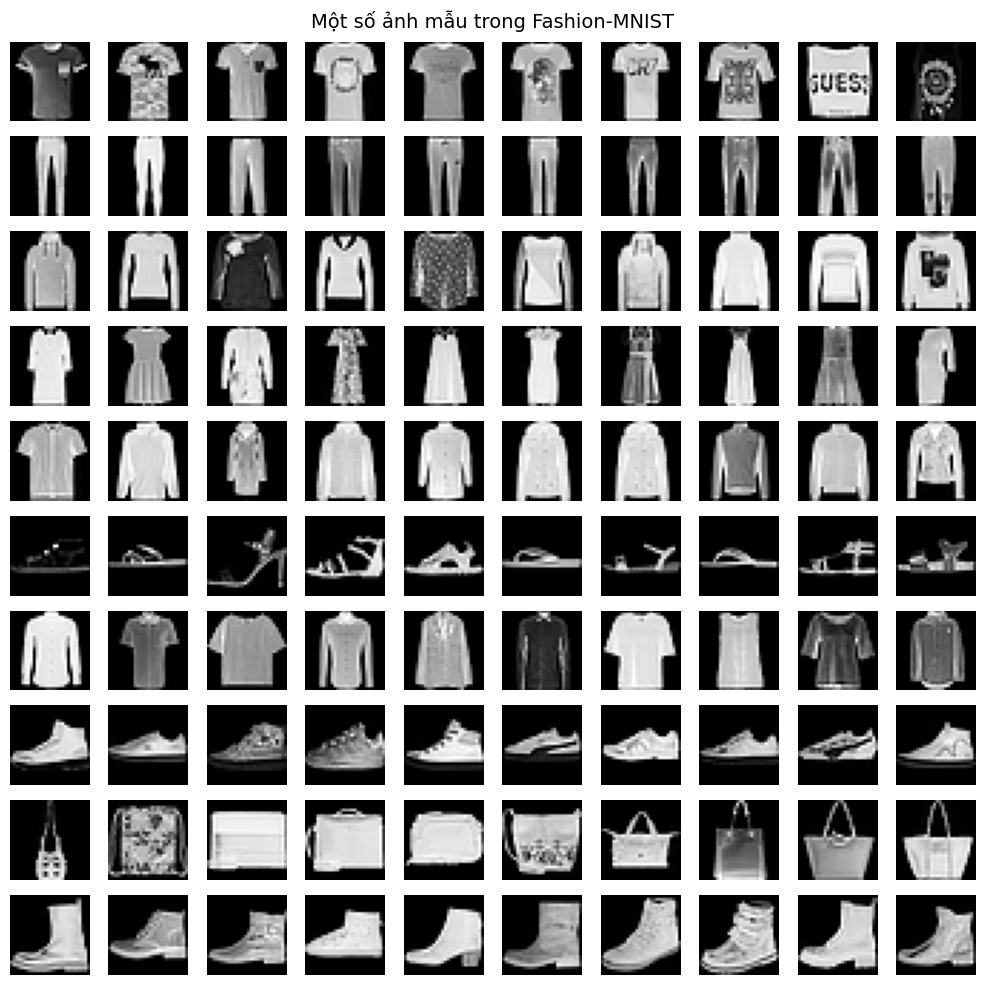

Đã lưu ảnh mẫu tại: /content/ket_qua_lab6/01_mau_du_lieu_fashion_mnist.png
Epoch 1/10 | Train Loss: 0.5063 | Train Acc: 81.22% | Val Loss: 0.5069 | Val Acc: 81.83%
Epoch 2/10 | Train Loss: 0.3705 | Train Acc: 86.35% | Val Loss: 0.3880 | Val Acc: 85.12%
Epoch 3/10 | Train Loss: 0.3310 | Train Acc: 87.76% | Val Loss: 0.3530 | Val Acc: 87.09%
Epoch 4/10 | Train Loss: 0.3052 | Train Acc: 88.71% | Val Loss: 0.3423 | Val Acc: 87.91%
Epoch 5/10 | Train Loss: 0.2835 | Train Acc: 89.46% | Val Loss: 0.3636 | Val Acc: 87.17%
Epoch 6/10 | Train Loss: 0.2713 | Train Acc: 89.84% | Val Loss: 0.3450 | Val Acc: 87.95%
Epoch 7/10 | Train Loss: 0.2578 | Train Acc: 90.37% | Val Loss: 0.3343 | Val Acc: 87.91%
Epoch 8/10 | Train Loss: 0.2461 | Train Acc: 90.80% | Val Loss: 0.3358 | Val Acc: 88.02%
Epoch 9/10 | Train Loss: 0.2352 | Train Acc: 91.06% | Val Loss: 0.3232 | Val Acc: 88.48%
Epoch 10/10 | Train Loss: 0.2264 | Train Acc: 91.37% | Val Loss: 0.3540 | Val Acc: 88.34%


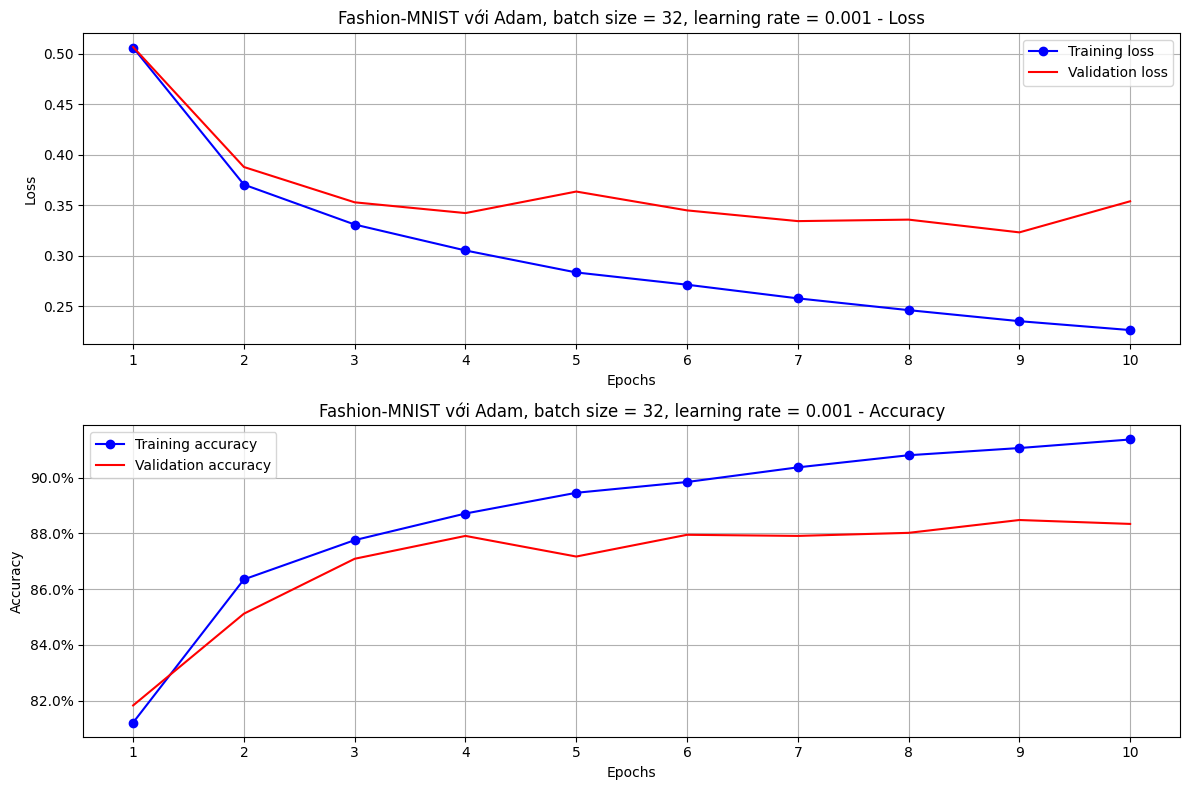

Đã lưu biểu đồ tại: /content/ket_qua_lab6/02_bieu_do_loss_accuracy.png


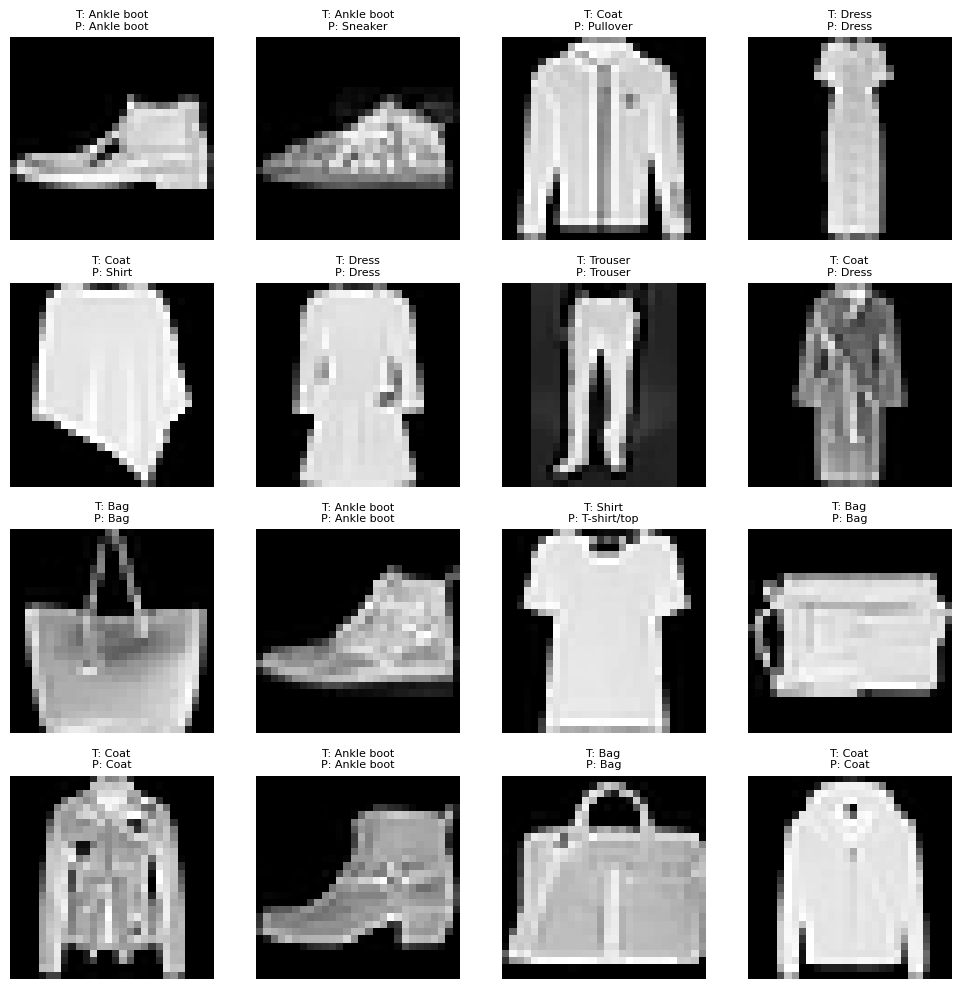

Đã lưu ảnh dự đoán tại:  /content/ket_qua_lab6/03_du_doan_anh_mau.png
Đã lưu model tại: /content/ket_qua_lab6/05_model_lab6_fashion_mnist.pth
Đã tạo file dataset zip: /content/dataset_FMNIST.zip
Đã tạo file kết quả zip: /content/ket_qua_lab6.zip

ĐÃ TẠO XONG FILE NỘP BÀI:
/content/Lab6_Nop_Bai.zip

Kiểm tra file:
Lab6_Nop_Bai.zip tồn tại: True
Kích thước file: 61.23228359222412 MB

Bắt đầu tải file Lab6_Nop_Bai.zip về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Nếu file chưa tự tải, hãy bấm biểu tượng thư mục bên trái Colab, tìm Lab6_Nop_Bai.zip rồi bấm Download.


In [8]:
# =========================================================
# LAB 6: XÂY DỰNG MẠNG NƠ-RON SÂU
# =========================================================

# =========================
# 1. Import thư viện
# =========================

import os
import shutil
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Thiết bị đang dùng:", device)


# =========================
# 2. Tạo thư mục
# =========================

data_folder = "/content/data/FMNIST"
result_folder = "/content/ket_qua_lab6"
submit_folder = "/content/Lab6_Nop_Bai"

os.makedirs(data_folder, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)
os.makedirs(submit_folder, exist_ok=True)

print("Thư mục dataset:", data_folder)
print("Thư mục kết quả:", result_folder)


# =========================
# 3. Tải dataset Fashion-MNIST
# =========================

fmnist = datasets.FashionMNIST(
    root=data_folder,
    download=True,
    train=True
)

val_fmnist = datasets.FashionMNIST(
    root=data_folder,
    download=True,
    train=False
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_images = val_fmnist.data
val_targets = val_fmnist.targets

print("\nThông tin dữ liệu:")
print("X train:", tr_images.shape)
print("Y train:", tr_targets.shape)
print("X test:", val_images.shape)
print("Y test:", val_targets.shape)
print("Các nhãn:", tr_targets.unique())
print("Số lớp:", len(tr_targets.unique()))
print("Tên các lớp:", fmnist.classes)


# =========================
# 4. Hiển thị mẫu dữ liệu
# =========================

def show_samples():
    R, C = len(tr_targets.unique()), 10
    fig, ax = plt.subplots(R, C, figsize=(10, 10))

    for label_class, plot_row in enumerate(ax):
        label_x_rows = np.where(tr_targets.numpy() == label_class)[0]

        for plot_cell in plot_row:
            plot_cell.grid(False)
            plot_cell.axis("off")
            ix = np.random.choice(label_x_rows)
            x = tr_images[ix]
            plot_cell.imshow(x, cmap="gray")

    plt.suptitle("Một số ảnh mẫu trong Fashion-MNIST", fontsize=14)
    plt.tight_layout()

    save_path = os.path.join(result_folder, "01_mau_du_lieu_fashion_mnist.png")
    plt.savefig(save_path, dpi=150)
    plt.show()

    print("Đã lưu ảnh mẫu tại:", save_path)

show_samples()


# =========================
# 5. Xây dựng Dataset
# =========================

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255.0
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y.long()

    def __getitem__(self, ix):
        return self.x[ix], self.y[ix]

    def __len__(self):
        return len(self.x)


# =========================
# 6. Tạo DataLoader
# =========================

def get_data(batch_size=32):
    train = FMNISTDataset(tr_images, tr_targets)
    val = FMNISTDataset(val_images, val_targets)

    trn_dl = DataLoader(
        train,
        batch_size=batch_size,
        shuffle=True
    )

    val_dl = DataLoader(
        val,
        batch_size=256,
        shuffle=False
    )

    return trn_dl, val_dl


# =========================
# 7. Xây dựng mạng nơ-ron sâu
# =========================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 512),
        nn.ReLU(),

        nn.Linear(512, 256),
        nn.ReLU(),

        nn.Linear(256, 128),
        nn.ReLU(),

        nn.Linear(128, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


# =========================
# 8. Hàm train một batch
# =========================

def train_batch(x, y, model, optimizer, loss_fn):
    model.train()

    x = x.to(device)
    y = y.to(device)

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    optimizer.zero_grad()
    batch_loss.backward()
    optimizer.step()

    is_correct = prediction.argmax(dim=1) == y

    return batch_loss.item(), is_correct.detach().cpu().numpy().tolist()


# =========================
# 9. Hàm validation
# =========================

@torch.no_grad()
def validate(val_dl, model, loss_fn):
    model.eval()

    val_losses = []
    val_accuracies = []

    for x, y in val_dl:
        x = x.to(device)
        y = y.to(device)

        prediction = model(x)
        loss = loss_fn(prediction, y)

        is_correct = prediction.argmax(dim=1) == y

        val_losses.append(loss.item())
        val_accuracies.extend(is_correct.detach().cpu().numpy().tolist())

    return np.mean(val_losses), np.mean(val_accuracies)


# =========================
# 10. Huấn luyện mô hình
# =========================

def fit(model, loss_fn, optimizer, trn_dl, val_dl, epochs=10):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(1, epochs + 1):
        train_epoch_losses = []
        train_epoch_accuracies = []

        for x, y in trn_dl:
            batch_loss, batch_accuracy = train_batch(
                x, y, model, optimizer, loss_fn
            )

            train_epoch_losses.append(batch_loss)
            train_epoch_accuracies.extend(batch_accuracy)

        train_epoch_loss = np.mean(train_epoch_losses)
        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        val_epoch_loss, val_epoch_accuracy = validate(
            val_dl, model, loss_fn
        )

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_accuracy)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_epoch_loss:.4f} | "
            f"Train Acc: {train_epoch_accuracy:.2%} | "
            f"Val Loss: {val_epoch_loss:.4f} | "
            f"Val Acc: {val_epoch_accuracy:.2%}"
        )

    history = {
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies
    }

    return history


# =========================
# 11. Vẽ biểu đồ Loss và Accuracy
# =========================

def plot_history(history):
    epochs = np.arange(1, len(history["train_losses"]) + 1)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history["train_losses"], "bo-", label="Training loss")
    plt.plot(epochs, history["val_losses"], "r-", label="Validation loss")
    plt.title("Fashion-MNIST với Adam, batch size = 32, learning rate = 0.001 - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.gca().xaxis.set_major_locator(mtick.MultipleLocator(1))
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history["train_accuracies"], "bo-", label="Training accuracy")
    plt.plot(epochs, history["val_accuracies"], "r-", label="Validation accuracy")
    plt.title("Fashion-MNIST với Adam, batch size = 32, learning rate = 0.001 - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.gca().xaxis.set_major_locator(mtick.MultipleLocator(1))
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    save_path = os.path.join(result_folder, "02_bieu_do_loss_accuracy.png")
    plt.savefig(save_path, dpi=150)
    plt.show()

    print("Đã lưu biểu đồ tại:", save_path)


# =========================
# 12. Chạy mô hình chính
# =========================

trn_dl, val_dl = get_data(batch_size=32)

model, loss_fn, optimizer = get_model()

history = fit(
    model,
    loss_fn,
    optimizer,
    trn_dl,
    val_dl,
    epochs=10
)

plot_history(history)


# =========================
# 13. Dự đoán thử một số ảnh
# =========================

@torch.no_grad()
def show_predictions(model, n=16):
    model.eval()

    idx = np.random.choice(len(val_images), n, replace=False)

    x = val_images[idx].float() / 255.0
    x = x.view(-1, 28 * 28).to(device)

    y_true = val_targets[idx]
    preds = model(x).argmax(dim=1).cpu()

    plt.figure(figsize=(10, 10))

    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(val_images[idx[i]], cmap="gray")
        plt.axis("off")

        true_label = fmnist.classes[int(y_true[i])]
        pred_label = fmnist.classes[int(preds[i])]

        plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8)

    plt.tight_layout()

    save_path = os.path.join(result_folder, "03_du_doan_anh_mau.png")
    plt.savefig(save_path, dpi=150)
    plt.show()

    print("Đã lưu ảnh dự đoán tại: ", save_path)

show_predictions(model)


# =========================
# 15. Lưu model
# =========================

model_path = os.path.join(result_folder, "05_model_lab6_fashion_mnist.pth")
torch.save(model.state_dict(), model_path)

print("Đã lưu model tại:", model_path)


# =========================
# 16. Nén dataset
# =========================

dataset_zip_path = "/content/dataset_FMNIST.zip"

if os.path.exists(dataset_zip_path):
    os.remove(dataset_zip_path)

shutil.make_archive(
    base_name="/content/dataset_FMNIST",
    format="zip",
    root_dir=data_folder
)

print("Đã tạo file dataset zip:", dataset_zip_path)


# =========================
# 17. Nén kết quả
# =========================

ketqua_zip_path = "/content/ket_qua_lab6.zip"

if os.path.exists(ketqua_zip_path):
    os.remove(ketqua_zip_path)

shutil.make_archive(
    base_name="/content/ket_qua_lab6",
    format="zip",
    root_dir=result_folder
)

print("Đã tạo file kết quả zip:", ketqua_zip_path)


# =========================
# 19. Gom tất cả vào 1 thư mục nộp bài
# =========================

# Xóa thư mục nộp bài cũ nếu có
if os.path.exists(submit_folder):
    shutil.rmtree(submit_folder)

os.makedirs(submit_folder, exist_ok=True)

# Copy các file cần nộp vào thư mục
shutil.copy(dataset_zip_path, os.path.join(submit_folder, "dataset_FMNIST.zip"))
shutil.copy(ketqua_zip_path, os.path.join(submit_folder, "ket_qua_lab6.zip"))

# Định nghĩa note_path và note
note_path = os.path.join(submit_folder, "note.txt")
note = "Đây là kết quả bài tập Lab 6 về xây dựng mạng nơ-ron sâu với Fashion-MNIST."

with open(note_path, "w", encoding="utf-8") as f:
    f.write(note)


# =========================
# 20. Nén thành 1 file duy nhất
# =========================

final_zip_path = "/content/Lab6_Nop_Bai.zip"

if os.path.exists(final_zip_path):
    os.remove(final_zip_path)

shutil.make_archive(
    base_name="/content/Lab6_Nop_Bai",
    format="zip",
    root_dir=submit_folder
)

print("\nĐÃ TẠO XONG FILE NỘP BÀI:")
print(final_zip_path)


# =========================
# 21. Kiểm tra file đã tồn tại chưa
# =========================

print("\nKiểm tra file:")
print("Lab6_Nop_Bai.zip tồn tại:", os.path.exists(final_zip_path))
print("Kích thước file:", os.path.getsize(final_zip_path) / (1024 * 1024), "MB")


# =========================
# 22. TỰ ĐỘNG TẢI FILE VỀ MÁY
# =========================

from google.colab import files

print("\nBắt đầu tải file Lab6_Nop_Bai.zip về máy...")
files.download(final_zip_path)

print("\nNếu file chưa tự tải, hãy bấm biểu tượng thư mục bên trái Colab, tìm Lab6_Nop_Bai.zip rồi bấm Download.")